<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Key_Bottlenecks_for_Quantum_Hardware.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.13.15 environment at: /usr
Checked 2 packages in 84ms


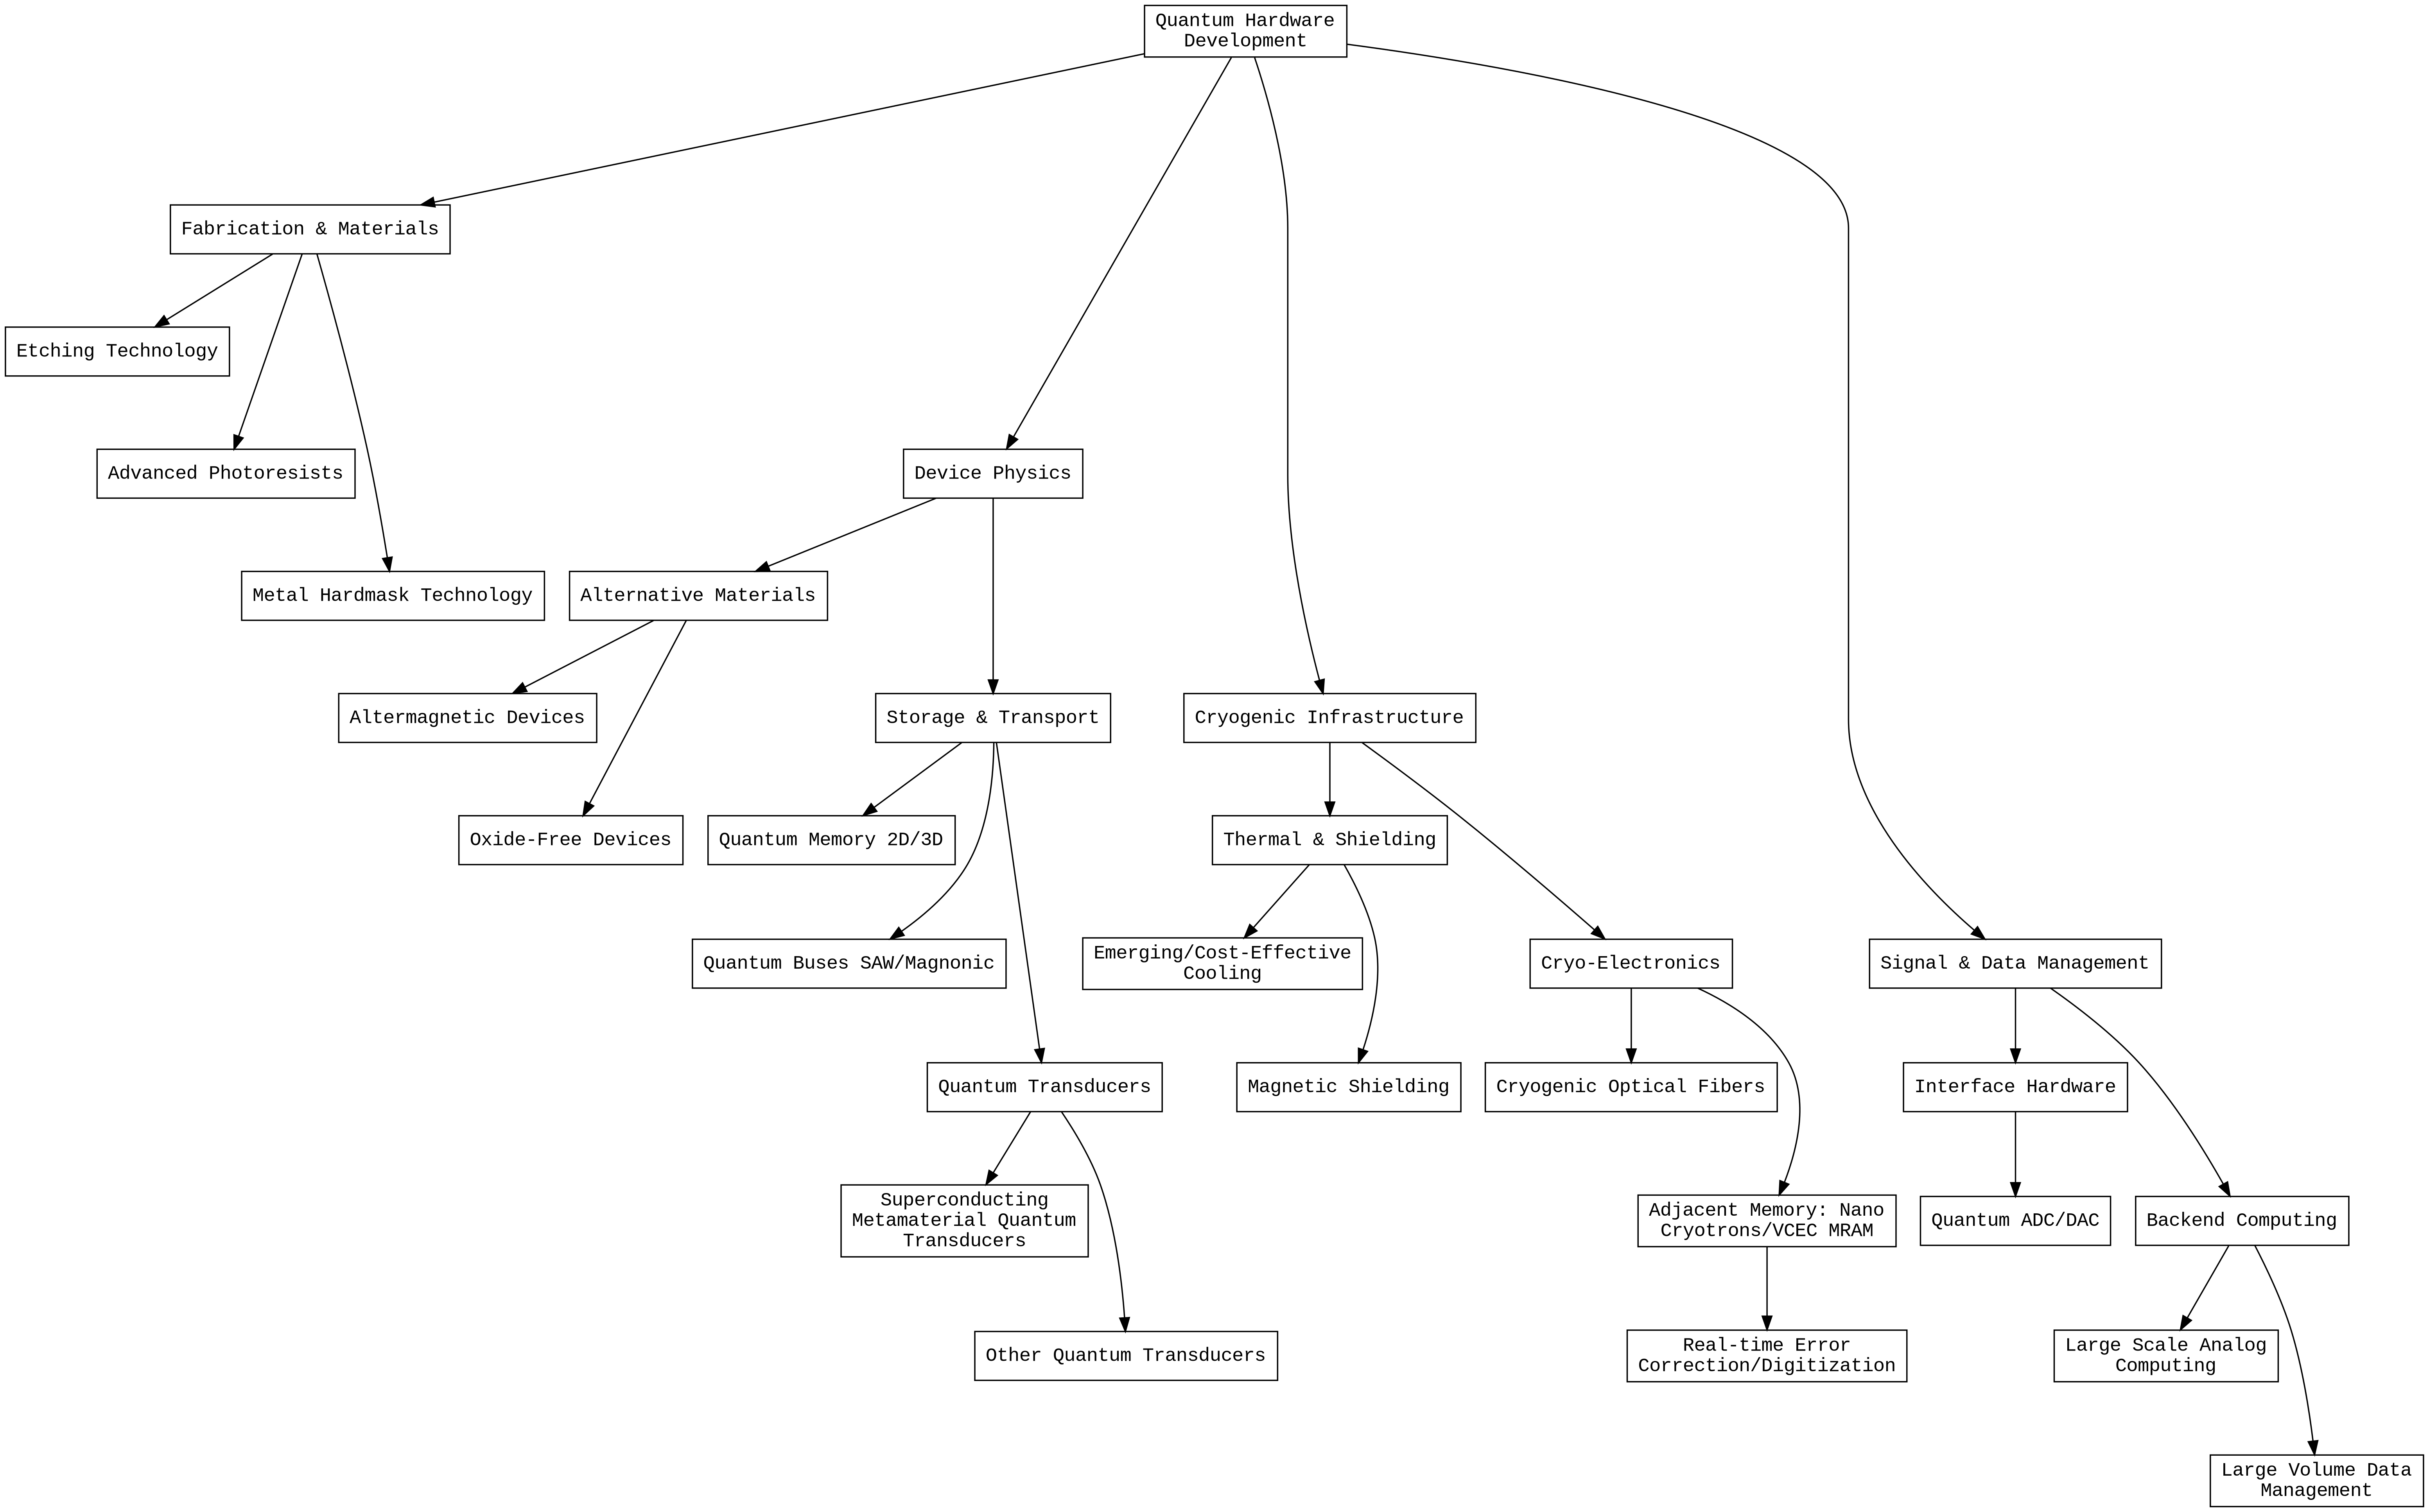

In [3]:
!uv pip install graphviz ipython

"""This script constructs a directed quantum hardware development graph and renders it as an in-memory downloadable object.
"""

import base64
import graphviz
from IPython.display import display, Image, HTML

# Control Knobs
GRAPH_DPI = "250"
NODE_FONT = "DejaVu Sans"
NODE_FONT_WEIGHT = "normal"
EDGE_ROUTING = "spline"
NODE_SHAPE = "box"
BACKGROUND_COLOR = "white"
FOREGROUND_COLOR = "black"
RANK_DIRECTION = "TB"
MAX_CHARACTERS_PER_LINE = 27
RANK_SEPARATION = "0.75"
VERTICAL_STAGGER_STEP = 2  # Multiplies the vertical drop distance between primary root branches

def wrap_text(text: str, max_width: int = MAX_CHARACTERS_PER_LINE) -> str:
    """Wraps text to a specified maximum width, hyphenating oversized strings.

    Args:
        text: The original string input.
        max_width: The maximum allowable characters per line.

    Returns:
        A formatted string featuring newline characters at proper intervals.
    """
    lines = []
    for paragraph in text.split('\n'):
        current_line = ""
        words = paragraph.split()
        for word in words:
            while len(word) > max_width:
                if current_line:
                    lines.append(current_line)
                    current_line = ""
                chunk = word[:max_width - 1] + "-"
                lines.append(chunk)
                word = word[max_width - 1:]

            if current_line:
                if len(current_line) + 1 + len(word) <= max_width:
                    current_line += " " + word
                else:
                    lines.append(current_line)
                    current_line = word
            else:
                current_line = word
        if current_line:
            lines.append(current_line)
    return '\n'.join(lines)

def build_hardware_development_tree() -> graphviz.Digraph:
    """Constructs the directed Graphviz object outlining the quantum hardware development hierarchy."""
    tree = graphviz.Digraph(format='png')

    tree.attr(dpi=GRAPH_DPI, splines=EDGE_ROUTING, bgcolor=BACKGROUND_COLOR, rankdir=RANK_DIRECTION, ranksep=RANK_SEPARATION)
    tree.attr('node', shape=NODE_SHAPE, style='solid', color=FOREGROUND_COLOR, fontcolor=FOREGROUND_COLOR, fontname=NODE_FONT)
    tree.attr('edge', color=FOREGROUND_COLOR, arrowhead='normal')

    tree.node('Root', wrap_text('Quantum Hardware Development'))

    # Level 1 Sub-branches
    tree.node('Fab', wrap_text('Fabrication & Materials'))
    tree.edge('Root', 'Fab', minlen=str(1 * VERTICAL_STAGGER_STEP))

    tree.node('Dev', wrap_text('Device Physics'))
    tree.edge('Root', 'Dev', minlen=str(2 * VERTICAL_STAGGER_STEP))

    tree.node('Cryo', wrap_text('Cryogenic Infrastructure'))
    tree.edge('Root', 'Cryo', minlen=str(3 * VERTICAL_STAGGER_STEP))

    tree.node('Data', wrap_text('Signal & Data Management'))
    tree.edge('Root', 'Data', minlen=str(4 * VERTICAL_STAGGER_STEP))

    # Fabrication & Materials children
    tree.node('Etch', wrap_text('Etching Technology'))
    tree.edge('Fab', 'Etch', minlen='1')

    tree.node('Photo', wrap_text('Advanced Photoresists'))
    tree.edge('Fab', 'Photo', minlen='2')

    tree.node('Mask', wrap_text('Metal Hardmask Technology'))
    tree.edge('Fab', 'Mask', minlen='3')

    # Device Physics children
    tree.node('AltMat', wrap_text('Alternative Materials'))
    tree.edge('Dev', 'AltMat', minlen='1')

    tree.node('Altermag', wrap_text('Altermagnetic Devices'))
    tree.edge('AltMat', 'Altermag', minlen='1')

    tree.node('OxideFree', wrap_text('Oxide-Free Devices'))
    tree.edge('AltMat', 'OxideFree', minlen='2')

    tree.node('Trans', wrap_text('Storage & Transport'))
    tree.edge('Dev', 'Trans', minlen='2')

    tree.node('QMem', wrap_text('Quantum Memory 2D/3D'))
    tree.edge('Trans', 'QMem', minlen='1')

    tree.node('QBuses', wrap_text('Quantum Buses SAW/Magnonic'))
    tree.edge('Trans', 'QBuses', minlen='2')

    tree.node('QTrans', wrap_text('Quantum Transducers'))
    tree.edge('Trans', 'QTrans', minlen='3')

    tree.node('QTrans_Meta', wrap_text('Superconducting Metamaterial Quantum Transducers'))
    tree.edge('QTrans', 'QTrans_Meta', minlen='1')

    tree.node('QTrans_Other', wrap_text('Other Quantum Transducers'))
    tree.edge('QTrans', 'QTrans_Other', minlen='2')

    # Cryogenic Infrastructure children
    tree.node('Thermal', wrap_text('Thermal & Shielding'))
    tree.edge('Cryo', 'Thermal', minlen='1')

    tree.node('Cool', wrap_text('Emerging/Cost-Effective Cooling'))
    tree.edge('Thermal', 'Cool', minlen='1')

    tree.node('Shield', wrap_text('Magnetic Shielding'))
    tree.edge('Thermal', 'Shield', minlen='2')

    tree.node('CryoElec', wrap_text('Cryo-Electronics'))
    tree.edge('Cryo', 'CryoElec', minlen='2')

    tree.node('Fibers', wrap_text('Cryogenic Optical Fibers'))
    tree.edge('CryoElec', 'Fibers', minlen='1')

    tree.node('AdjMem', wrap_text('Adjacent Memory: Nano Cryotrons/VCEC MRAM'))
    tree.edge('CryoElec', 'AdjMem', minlen='2')

    tree.node('ECC', wrap_text('Real-time Error Correction/Digitization'))
    tree.edge('AdjMem', 'ECC', minlen='1')

    # Signal & Data Management children
    tree.node('Interface', wrap_text('Interface Hardware'))
    tree.edge('Data', 'Interface', minlen='1')

    tree.node('ADC', wrap_text('Quantum ADC/DAC'))
    tree.edge('Interface', 'ADC', minlen='1')

    tree.node('Backend', wrap_text('Backend Computing'))
    tree.edge('Data', 'Backend', minlen='2')

    tree.node('Analog', wrap_text('Large Scale Analog Computing'))
    tree.edge('Backend', 'Analog', minlen='1')

    tree.node('DataMgmt', wrap_text('Large Volume Data Management'))
    tree.edge('Backend', 'DataMgmt', minlen='2')

    return tree

def display_and_generate_download(tree: graphviz.Digraph) -> None:
    """Renders the graph in memory and constructs a base64 encoded download button."""
    binary_png = tree.pipe(format='png')

    display(Image(data=binary_png))

    encoded_image = base64.b64encode(binary_png).decode('utf-8')

if __name__ == '__main__':
    hardware_tree = build_hardware_development_tree()
    display_and_generate_download(hardware_tree)